In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.
    aln.params.sigmai_ext = 0.
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.


In [3]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

max delay =  0


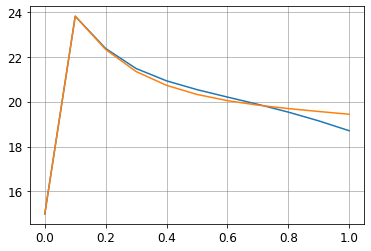

In [8]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars
    
state_vars = aln.state_vars
init_vars = aln.init_vars

In [5]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-16

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [6]:
def plot_fig(i):
    lines = 8
    fig, axes = plt.subplots(lines,2, figsize=(18, 12))
    axes[0,i].plot(aln.t, control1[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control1[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

In [17]:
#setparams()

dur = 1.
aln.params.duration = dur
aln.params.di = 0.0

target = aln.getZeroTarget()

s_range = np.arange(0., 5., 0.1)
print(s_range)

control1 = aln.getZeroControl()
control1[0,1,8] += 1.
control2 = aln.getZeroControl()

max_cntrl = 50. * 5.
start_step = 1e3
cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])
max_it = 25

improve = np.zeros( (len(s_range), len(s_range)) )

for s_exc in range(len(s_range)):
    for s_inh in range(len(s_range)):
        print("---------------------------------------")
        print(s_exc, s_inh)
        aln.params.sigmae_ext = s_range[s_exc]
        aln.params.sigmai_ext = s_range[s_inh]
        set_init(initvars)

        aln.run(control=control1)

        target[:,0,:] = aln.state["rates_exc"][0,:]
        target[:,1,:] = aln.state["rates_inh"][0,:]
        

        set_init(initvars)

        A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
            u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            variables_ = [0])
        
        improve[s_exc, s_inh] = A1_cost[-1]/A1_cost[0]
        


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9]
set cost params
---------------------------------------
0 0
True 0
RUN  0 , total integrated cost =  6.272565223083823e-05
RUN  1 , total integrated cost =  3.182335518000046e-05
RUN  2 , total integrated cost =  3.09502833113436e-05
RUN  3 , total integrated cost =  3.0124243204501932e-05
RUN  4 , total integrated cost =  2.9441396528248264e-05
RUN  5 , total integrated cost =  2.876939997718481e-05
RUN  6 , total integrated cost =  2.8022180802038025e-05
RUN  7 , total integrated cost =  2.7253885353992903e-05
RUN  8 , total integrated cost =  2.6670379640961755e-05
RUN  9 , total integrated cost =  2.609786482348484e-05
RUN  10 , total integrated cost =  2.5398043994541913e-05
RUN  11 , total integrated cost =  2.47407405186936e-05
RUN  12 , total integrated cost =  2.42037276150469

RUN  22 , total integrated cost =  1.9197808586146172e-05
RUN  23 , total integrated cost =  1.869257682751472e-05
RUN  24 , total integrated cost =  1.8329734232801084e-05
RUN  25 , total integrated cost =  1.797249169791593e-05
Improved over  25  iterations by  71.34746143128984  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 0.001173451093388206
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -0.0004730449196488678
---------------------------------------
0 1
True 0
RUN  0 , total integrated cost =  6.284305223196126e-05
RUN  1 , total integrated cost =  3.187768620109316e-05
RUN  2 , total integrated cost =  3.121635341534156e-05
RUN  3 , total integrated cost =  3.0555618210356545e-05
RUN  4 , total integrated cost =  2.9990420018385858e-05
RUN  5 , total integrated cost =  2.9459661819562617e-05
RUN  6 , total integrated cost =  2.894917

RUN  19 , total integrated cost =  2.2878803654710383e-05
RUN  20 , total integrated cost =  2.2448233051675484e-05
RUN  21 , total integrated cost =  2.2013849631733425e-05
RUN  22 , total integrated cost =  2.161782758916445e-05
RUN  23 , total integrated cost =  2.122475404930031e-05
RUN  24 , total integrated cost =  2.082450835373912e-05
RUN  25 , total integrated cost =  2.0431670846623828e-05
Improved over  25  iterations by  67.48778087479253  percent.
max value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([2], dtype=int64)) -0.0006957473711054833
---------------------------------------
0 2
True 0
RUN  0 , total integrated cost =  6.275861776594288e-05
RUN  1 , total integrated cost =

RUN  16 , total integrated cost =  2.187837174274826e-05
RUN  17 , total integrated cost =  2.1449830587942477e-05
RUN  18 , total integrated cost =  2.1063442223888508e-05
RUN  19 , total integrated cost =  2.0684708921590214e-05
RUN  20 , total integrated cost =  2.028491694530482e-05
RUN  21 , total integrated cost =  1.9885777154719457e-05
RUN  22 , total integrated cost =  1.942774695114795e-05
RUN  23 , total integrated cost =  1.9015212760960705e-05
RUN  24 , total integrated cost =  1.8545555747528434e-05
RUN  25 , total integrated cost =  1.8111542753856178e-05
Improved over  25  iterations by  71.14094701479429  percent.
max value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([2], dt

RUN  16 , total integrated cost =  1.5810341970599014e-05
RUN  17 , total integrated cost =  1.5400828714297372e-05
RUN  18 , total integrated cost =  1.4714560047639317e-05
RUN  19 , total integrated cost =  1.4080281663732953e-05
RUN  20 , total integrated cost =  1.3560090192708878e-05
RUN  21 , total integrated cost =  1.3089341946324237e-05
RUN  22 , total integrated cost =  1.2516960529324712e-05
RUN  23 , total integrated cost =  1.1961397141000813e-05
RUN  24 , total integrated cost =  1.1573637514628814e-05
RUN  25 , total integrated cost =  1.1211755400600414e-05
Improved over  25  iterations by  81.9940660771642  percent.
max value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], 

...

RUN  8 , total integrated cost =  2.4714254633572793e-05
RUN  9 , total integrated cost =  2.3972064235779612e-05
RUN  10 , total integrated cost =  2.2537745050041608e-05
RUN  11 , total integrated cost =  2.1239165705543797e-05
RUN  12 , total integrated cost =  2.0598144140427335e-05
RUN  13 , total integrated cost =  1.99301293972349e-05
RUN  14 , total integrated cost =  1.896185104176736e-05
RUN  15 , total integrated cost =  1.807422358875413e-05
RUN  16 , total integrated cost =  1.7514773420014277e-05
RUN  17 , total integrated cost =  1.7012743864105162e-05
RUN  18 , total integrated cost =  1.6155457446512155e-05
RUN  19 , total integrated cost =  1.530838054823722e-05
RUN  20 , total integrated cost =  1.4905651653395592e-05
RUN  21 , total integrated cost =  1.4531839055386396e-05
RUN  22 , total integrated cost =  1.4275796473115627e-05
RUN  23 , total integrated cost =  1.4011189679583657e-05
RUN  24 , total integrated cost =  1.3683759058575548e-05
RUN  25 , total integ

RUN  22 , total integrated cost =  1.4042122826815706e-05
RUN  23 , total integrated cost =  1.3699483233434076e-05
RUN  24 , total integrated cost =  1.3364945346073892e-05
RUN  25 , total integrated cost =  1.3051146594927184e-05
Improved over  25  iterations by  76.56752826707772  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 0.0010072346389518962
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -0.00034424549176577304
---------------------------------------
5 13
True 0
RUN  0 , total integrated cost =  5.415712187747768e-05
RUN  1 , total integrated cost =  2.775294157826802e-05
RUN  2 , total integrated cost =  2.729241882738307e-05
RUN  3 , total integrated cost =  2.684601765709938e-05
RUN  4 , total integrated cost =  2.6390516730807983e-05
RUN  5 , total integrated cost =  2.5949611434970127e-05
RUN  6 , total integrated cost =  2.55

RUN  4 , total integrated cost =  2.317359103691504e-05
RUN  5 , total integrated cost =  2.2651020863496288e-05
RUN  6 , total integrated cost =  2.2041254087545967e-05
RUN  7 , total integrated cost =  2.1421942055829223e-05
RUN  8 , total integrated cost =  2.0558524764513915e-05
RUN  9 , total integrated cost =  1.9727311414262676e-05
RUN  10 , total integrated cost =  1.919464337752879e-05
RUN  11 , total integrated cost =  1.8628250660425994e-05
RUN  12 , total integrated cost =  1.7964174465669453e-05
RUN  13 , total integrated cost =  1.729461603699896e-05
RUN  14 , total integrated cost =  1.6820337603689086e-05
RUN  15 , total integrated cost =  1.635572738852057e-05
RUN  16 , total integrated cost =  1.5769006487468177e-05
RUN  17 , total integrated cost =  1.5214917497487335e-05
RUN  18 , total integrated cost =  1.4801182556513208e-05
RUN  19 , total integrated cost =  1.4411075937422374e-05
RUN  20 , total integrated cost =  1.3902950203835454e-05
RUN  21 , total integrat

RUN  15 , total integrated cost =  1.660472265325446e-05
RUN  16 , total integrated cost =  1.628914360755688e-05
RUN  17 , total integrated cost =  1.5988531326960287e-05
RUN  18 , total integrated cost =  1.5682747598023e-05
RUN  19 , total integrated cost =  1.539987249443903e-05
RUN  20 , total integrated cost =  1.5102715020234636e-05
RUN  21 , total integrated cost =  1.4803781481640793e-05
RUN  22 , total integrated cost =  1.454666817623999e-05
RUN  23 , total integrated cost =  1.4299122922790189e-05
RUN  24 , total integrated cost =  1.4014444981189596e-05
RUN  25 , total integrated cost =  1.3721984854507e-05
Improved over  25  iterations by  68.05452110140541  percent.
max value of final gradient at index =  (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  9, 10],
      dtype=int64)) 0.0
min value of final gradient at index =  (array([0], d

KeyboardInterrupt: 

In [13]:
for s_exc in range(len(s_range)):
    for s_inh in range(len(s_range)):
        print("sigma exc = ", s_range[s_exc])
        print("sigma inh = ", s_range[s_inh])
        print("improved by = ", improve[s_exc, s_inh])

sigma exc =  0.0
sigma inh =  0.0
improved by =  0.4049068138992631
sigma exc =  0.0
sigma inh =  0.1
improved by =  0.42943736497583584
sigma exc =  0.0
sigma inh =  0.2
improved by =  0.4042779807981069
sigma exc =  0.0
sigma inh =  0.30000000000000004
improved by =  0.3289807476036023
sigma exc =  0.0
sigma inh =  0.4
improved by =  0.3272344379848356
sigma exc =  0.0
sigma inh =  0.5
improved by =  0.4391587680522702
sigma exc =  0.0
sigma inh =  0.6000000000000001
improved by =  0.42828574633113364
sigma exc =  0.0
sigma inh =  0.7000000000000001
improved by =  0.3938998352952416
sigma exc =  0.0
sigma inh =  0.8
improved by =  0.03435656889514516
sigma exc =  0.0
sigma inh =  0.9
improved by =  0.41366377542449634
sigma exc =  0.0
sigma inh =  1.0
improved by =  0.456895088074045
sigma exc =  0.0
sigma inh =  1.1
improved by =  0.3928961843732162
sigma exc =  0.0
sigma inh =  1.2000000000000002
improved by =  0.01472683293327387
sigma exc =  0.0
sigma inh =  1.3
improved by =  0.

sigma inh =  1.0
improved by =  0.368674681520726
sigma exc =  0.9
sigma inh =  1.1
improved by =  0.03373530586010835
sigma exc =  0.9
sigma inh =  1.2000000000000002
improved by =  0.41137142809254834
sigma exc =  0.9
sigma inh =  1.3
improved by =  0.4450387955430119
sigma exc =  0.9
sigma inh =  1.4000000000000001
improved by =  0.39615916180185434
sigma exc =  0.9
sigma inh =  1.5
improved by =  0.02807417112977708
sigma exc =  0.9
sigma inh =  1.6
improved by =  0.4166790450999533
sigma exc =  0.9
sigma inh =  1.7000000000000002
improved by =  0.43508370425972476
sigma exc =  0.9
sigma inh =  1.8
improved by =  0.092041181146416
sigma exc =  0.9
sigma inh =  1.9000000000000001
improved by =  0.3100861004836504
sigma exc =  0.9
sigma inh =  2.0
improved by =  0.436894163199799
sigma exc =  0.9
sigma inh =  2.1
improved by =  0.3787644118418341
sigma exc =  0.9
sigma inh =  2.2
improved by =  0.31368473082920584
sigma exc =  0.9
sigma inh =  2.3000000000000003
improved by =  0.4452

improved by =  0.4021472600120223
sigma exc =  1.7000000000000002
sigma inh =  2.7
improved by =  0.036925379449298336
sigma exc =  1.7000000000000002
sigma inh =  2.8000000000000003
improved by =  0.4244787384235709
sigma exc =  1.7000000000000002
sigma inh =  2.9000000000000004
improved by =  0.46252143487827885
sigma exc =  1.7000000000000002
sigma inh =  3.0
improved by =  0.43520799286156864
sigma exc =  1.7000000000000002
sigma inh =  3.1
improved by =  0.06303188134641767
sigma exc =  1.7000000000000002
sigma inh =  3.2
improved by =  0.35383326752820693
sigma exc =  1.7000000000000002
sigma inh =  3.3000000000000003
improved by =  0.46368274207531557
sigma exc =  1.7000000000000002
sigma inh =  3.4000000000000004
improved by =  0.4404231002396465
sigma exc =  1.7000000000000002
sigma inh =  3.5
improved by =  0.03371251907438372
sigma exc =  1.7000000000000002
sigma inh =  3.6
improved by =  0.4140127617034858
sigma exc =  1.7000000000000002
sigma inh =  3.7
improved by =  0.45

improved by =  0.04914967206696104
sigma exc =  2.7
sigma inh =  1.5
improved by =  0.4414482961777406
sigma exc =  2.7
sigma inh =  1.6
improved by =  0.16846624966614399
sigma exc =  2.7
sigma inh =  1.7000000000000002
improved by =  0.37481042372204887
sigma exc =  2.7
sigma inh =  1.8
improved by =  0.4143873428528558
sigma exc =  2.7
sigma inh =  1.9000000000000001
improved by =  0.44751810957806026
sigma exc =  2.7
sigma inh =  2.0
improved by =  0.43708148644044464
sigma exc =  2.7
sigma inh =  2.1
improved by =  0.11047455170601057
sigma exc =  2.7
sigma inh =  2.2
improved by =  0.412063831278935
sigma exc =  2.7
sigma inh =  2.3000000000000003
improved by =  0.4502198179539344
sigma exc =  2.7
sigma inh =  2.4000000000000004
improved by =  0.4245367004164424
sigma exc =  2.7
sigma inh =  2.5
improved by =  0.1298654382871958
sigma exc =  2.7
sigma inh =  2.6
improved by =  0.3490478757643099
sigma exc =  2.7
sigma inh =  2.7
improved by =  0.4493753255973119
sigma exc =  2.7


sigma inh =  4.3
improved by =  0.3728853739172951
sigma exc =  3.5
sigma inh =  4.4
improved by =  0.4272475202304515
sigma exc =  3.5
sigma inh =  4.5
improved by =  0.43569820678387433
sigma exc =  3.5
sigma inh =  4.6000000000000005
improved by =  0.37667534727826013
sigma exc =  3.5
sigma inh =  4.7
improved by =  0.14550316981926315
sigma exc =  3.5
sigma inh =  4.800000000000001
improved by =  0.41185494821351487
sigma exc =  3.5
sigma inh =  4.9
improved by =  0.44725608938860023
sigma exc =  3.6
sigma inh =  0.0
improved by =  0.40324573332502034
sigma exc =  3.6
sigma inh =  0.1
improved by =  0.4109773033358704
sigma exc =  3.6
sigma inh =  0.2
improved by =  0.42234727403775585
sigma exc =  3.6
sigma inh =  0.30000000000000004
improved by =  0.4306233380390024
sigma exc =  3.6
sigma inh =  0.4
improved by =  0.4199078801833473
sigma exc =  3.6
sigma inh =  0.5
improved by =  0.34409388249488604
sigma exc =  3.6
sigma inh =  0.6000000000000001
improved by =  0.11483319075477

sigma inh =  2.5
improved by =  0.10619728687722957
sigma exc =  4.5
sigma inh =  2.6
improved by =  0.41653677616010004
sigma exc =  4.5
sigma inh =  2.7
improved by =  0.15562031497276066
sigma exc =  4.5
sigma inh =  2.8000000000000003
improved by =  0.3178171808221192
sigma exc =  4.5
sigma inh =  2.9000000000000004
improved by =  0.4203092068321029
sigma exc =  4.5
sigma inh =  3.0
improved by =  0.35960248421289853
sigma exc =  4.5
sigma inh =  3.1
improved by =  0.3201411773288759
sigma exc =  4.5
sigma inh =  3.2
improved by =  0.37976598183781757
sigma exc =  4.5
sigma inh =  3.3000000000000003
improved by =  0.13509294856240847
sigma exc =  4.5
sigma inh =  3.4000000000000004
improved by =  0.33879517660760283
sigma exc =  4.5
sigma inh =  3.5
improved by =  0.32429504725105934
sigma exc =  4.5
sigma inh =  3.6
improved by =  0.4311320644653052
sigma exc =  4.5
sigma inh =  3.7
improved by =  0.371851472887916
sigma exc =  4.5
sigma inh =  3.8000000000000003
improved by =  0.

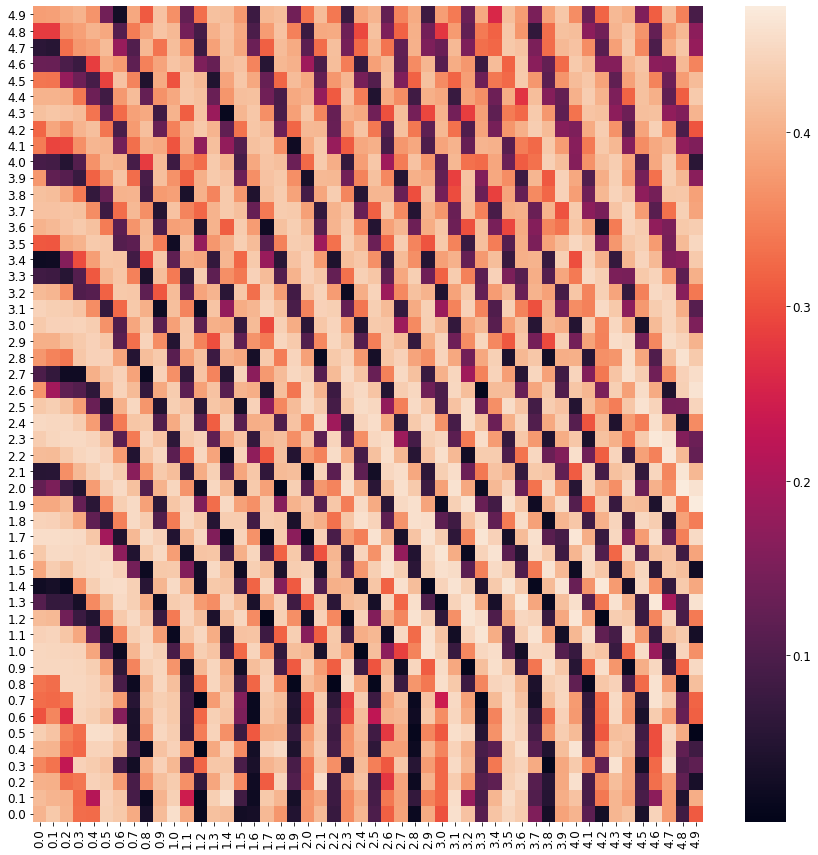

In [16]:
import seaborn as sns

x_axis_labels = np.around(s_range,2)
y_axis_labels = np.around(s_range,2)

fig, ax = plt.subplots(figsize=(15,15))
ax = sns.heatmap(improve, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
ax.invert_yaxis()
plt.savefig("sigma_range_convergence.pdf")